# Support Vector Machines - Exercise 1

In this exercise, we'll be using support vector machines (SVMs) to build a spam classifier.  We'll start with SVMs on some simple 2D data sets to see how they work.  Then we'll do some pre-processing work on a set of raw emails and build a classifier on the processed emails using a SVM to determine if they are spam or not.

The first thing we're going to do is look at a simple 2-dimensional data set and see how a linear SVM works on the data set for varying values of C (similar to the regularization term in linear/logistic regression).  Let's load the data.
## Exercise 1
#### 1. Load libraries

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.svm import SVC
from sklearn import metrics

import scipy.io as sio

#### 1. Load the data `ejer_1_data2.mat`

In [2]:
mat = sio.loadmat("data/ejer_1_data2.mat")
mat.keys()

dict_keys(['__header__', '__version__', '__globals__', 'X', 'y'])

In [4]:
mat["X"]

array([[0.107143 , 0.60307  ],
       [0.093318 , 0.649854 ],
       [0.0979263, 0.705409 ],
       ...,
       [0.975806 , 0.439474 ],
       [0.989631 , 0.425439 ],
       [0.996544 , 0.414912 ]])

In [5]:
mat["y"]

array([[1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
    

#### 2. Create a DataFrame with the features and target

In [6]:
df = pd.DataFrame(mat["X"],columns= ["x1", "x2"])
df["y"] = mat["y"]
df

,x1,x2,y
0,0.107143,0.603070,1
1,0.093318,0.649854,1
2,0.097926,0.705409,1
3,0.155530,0.784357,1
4,0.210829,0.866228,1
...,...,...,...
858,0.994240,0.516667,1
859,0.964286,0.472807,1
860,0.975806,0.439474,1
861,0.989631,0.425439,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 863 entries, 0 to 862
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      863 non-null    float64
 1   x2      863 non-null    float64
 2   y       863 non-null    uint8  
dtypes: float64(2), uint8(1)
memory usage: 14.5 KB


In [8]:
df.describe()

,x1,x2,y
count,863.000000,863.000000,863.000000
mean,0.503414,0.694304,0.556199
std,0.254967,0.158884,0.497120
min,0.044931,0.402632,0.000000
25%,0.292627,0.557018,0.000000
50%,0.512673,0.693713,1.000000
75%,0.699309,0.830409,1.000000
max,0.998848,0.988596,1.000000


In [10]:
df["y"].value_counts(normalize= True)

y
1    0.556199
0    0.443801
Name: proportion, dtype: float64

#### 3. Plot a scatterplot with the data

<Axes: xlabel='x1', ylabel='x2'>

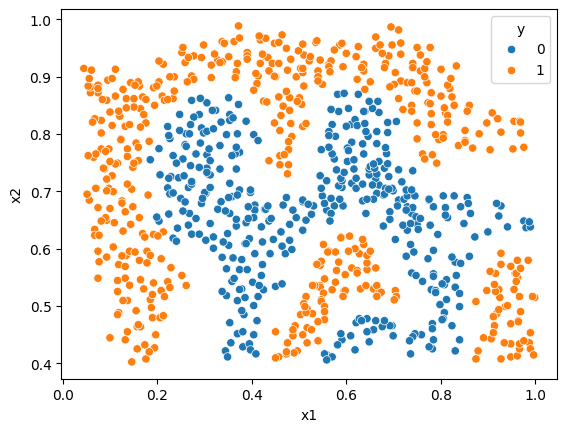

In [11]:
sns.scatterplot(df, x = "x1", y = "x2", hue= "y")

For this data set we'll build a support vector machine classifier using the built-in RBF kernel and examine its accuracy on the training data.  To visualize the decision boundary, this time we'll shade the points based on the predicted probability that the instance has a negative class label.  We'll see from the result that it gets most of them right.

In [ ]:
# SVC DE KERNEL LINEAL

#### 4. Declare a SVC with this hyperparameters
```Python
SVC(C=100, gamma=10, probability=True)
```


In [13]:
svc = SVC(C=100, gamma=10, probability= True)

#### 5. Fit the classifier and get the score

In [14]:
X = df[["x1", "x2"]]
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)


(690, 2)
(690,)
(173, 2)
(173,)


In [37]:
st_scaler = StandardScaler()
st_scaler.fit(X_train)
X_train_sc = st_scaler.transform(X_train)
X_test_sc = st_scaler.transform(X_test)

In [16]:
svc.fit(X_train_sc, y_train)

SVC(C=100, gamma=10, probability=True)

In [17]:
svc.score(X_train_sc, y_train)

1.0

#### 6. Plot the scatter plot and probability of predicting 0 with a [sequential color](https://matplotlib.org/3.1.1/tutorials/colors/colormaps.html)

In [18]:
pred = svc.predict_proba(X_test_sc)
pred

array([[8.71605934e-07, 9.99999128e-01],
       [9.99994315e-01, 5.68512711e-06],
       [4.69104668e-02, 9.53089533e-01],
       [1.17642312e-05, 9.99988236e-01],
       [6.05890616e-03, 9.93941094e-01],
       [9.99506628e-01, 4.93371540e-04],
       [3.31318232e-03, 9.96686818e-01],
       [8.85120963e-03, 9.91148790e-01],
       [9.99876437e-01, 1.23563140e-04],
       [9.90688339e-01, 9.31166106e-03],
       [9.37932539e-01, 6.20674608e-02],
       [9.99971051e-01, 2.89492109e-05],
       [2.98141069e-03, 9.97018589e-01],
       [9.99391731e-01, 6.08269076e-04],
       [9.90210786e-01, 9.78921355e-03],
       [9.93227261e-01, 6.77273888e-03],
       [9.95339033e-01, 4.66096737e-03],
       [5.63234789e-03, 9.94367652e-01],
       [9.99999900e-01, 1.00000010e-07],
       [9.96013287e-01, 3.98671274e-03],
       [7.80805558e-03, 9.92191944e-01],
       [8.24714444e-03, 9.91752856e-01],
       [9.98802860e-01, 1.19713973e-03],
       [4.17330273e-06, 9.99995827e-01],
       [9.935695

In [26]:
X_train

,x1,x2
11,0.750000,0.819444
749,0.372120,0.988596
143,0.538018,0.962719
566,0.842166,0.673246
615,0.448157,0.900877
...,...,...
269,0.526498,0.660088
337,0.867512,0.775585
91,0.567972,0.927632
80,0.413594,0.901316


In [25]:
X_test.iloc[:, 0]

104    0.738479
475    0.240783
747    0.694700
31     0.215438
365    0.111751
         ...   
334    0.750000
568    0.726959
597    0.091014
317    0.777650
490    0.574885
Name: x1, Length: 173, dtype: float64

In [27]:
pred

array([[8.71605934e-07, 9.99999128e-01],
       [9.99994315e-01, 5.68512711e-06],
       [4.69104668e-02, 9.53089533e-01],
       [1.17642312e-05, 9.99988236e-01],
       [6.05890616e-03, 9.93941094e-01],
       [9.99506628e-01, 4.93371540e-04],
       [3.31318232e-03, 9.96686818e-01],
       [8.85120963e-03, 9.91148790e-01],
       [9.99876437e-01, 1.23563140e-04],
       [9.90688339e-01, 9.31166106e-03],
       [9.37932539e-01, 6.20674608e-02],
       [9.99971051e-01, 2.89492109e-05],
       [2.98141069e-03, 9.97018589e-01],
       [9.99391731e-01, 6.08269076e-04],
       [9.90210786e-01, 9.78921355e-03],
       [9.93227261e-01, 6.77273888e-03],
       [9.95339033e-01, 4.66096737e-03],
       [5.63234789e-03, 9.94367652e-01],
       [9.99999900e-01, 1.00000010e-07],
       [9.96013287e-01, 3.98671274e-03],
       [7.80805558e-03, 9.92191944e-01],
       [8.24714444e-03, 9.91752856e-01],
       [9.98802860e-01, 1.19713973e-03],
       [4.17330273e-06, 9.99995827e-01],
       [9.935695

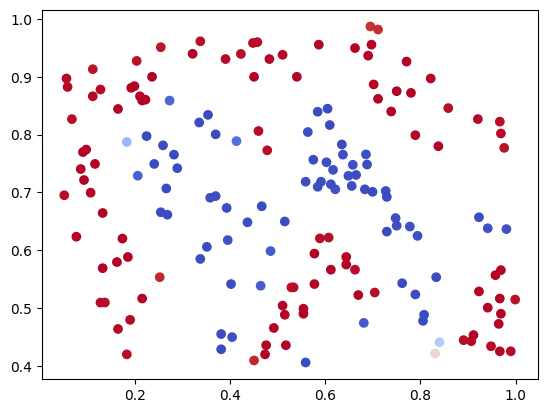

In [28]:
plt.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], c=pred[:, 1], cmap = "coolwarm")

## Metricas

In [33]:
pred_2 = svc.predict(X_test_sc)
print(metrics.accuracy_score(y_test, pred_2))
print(metrics.precision_score(y_test, pred_2))
print(metrics.recall_score(y_test, pred_2))

print(metrics.classification_report(y_test, pred_2))

0.9942196531791907
1.0
0.9902912621359223
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        70
           1       1.00      0.99      1.00       103

    accuracy                           0.99       173
   macro avg       0.99      1.00      0.99       173
weighted avg       0.99      0.99      0.99       173



<Axes: >

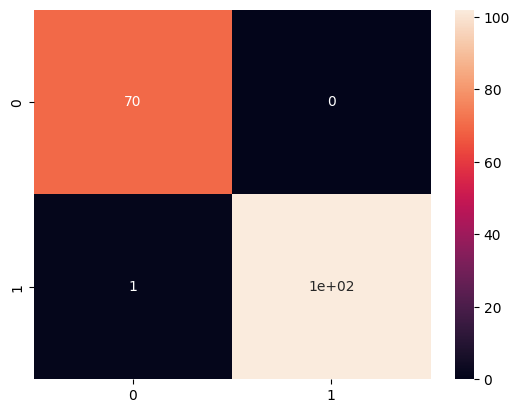

In [34]:
sns.heatmap(metrics.confusion_matrix(y_test, pred_2), annot= True)

## Entrenamiento modelo con todos los datos.

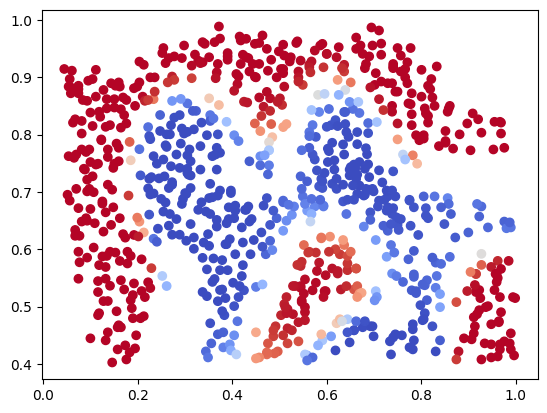

In [ ]:
st_scaler = StandardScaler()
st_scaler.fit(X)
X_train_sc_2 = st_scaler.transform(X)


svc_2 = SVC(C=100, gamma=10, probability= True)
svc_2.fit(X, y)

pred = svc_2.predict_proba(X)

plt.scatter(df["x1"], df["x2"], c=pred[:, 1], cmap = "coolwarm")

#### Grid search

In [60]:
svc = SVC(random_state=11, probability= True)

parametros={
    "kernel" : ["linear", "poly", "rbf"],
    "C": np.arange(0, 100)
}

gs_svc = GridSearchCV(estimator= svc, param_grid= parametros, scoring="accuracy", cv = 5, verbose=3)
gs_svc.fit(X_train_sc, y_train)

Fitting 5 folds for each of 300 candidates, totalling 1500 fits
[CV 1/5] END ..................C=0, kernel=linear;, score=nan total time=   0.0s
[CV 2/5] END ..................C=0, kernel=linear;, score=nan total time=   0.0s
[CV 3/5] END ..................C=0, kernel=linear;, score=nan total time=   0.0s
[CV 4/5] END ..................C=0, kernel=linear;, score=nan total time=   0.0s
[CV 5/5] END ..................C=0, kernel=linear;, score=nan total time=   0.0s
[CV 1/5] END ....................C=0, kernel=poly;, score=nan total time=   0.0s
[CV 2/5] END ....................C=0, kernel=poly;, score=nan total time=   0.0s
[CV 3/5] END ....................C=0, kernel=poly;, score=nan total time=   0.0s
[CV 4/5] END ....................C=0, kernel=poly;, score=nan total time=   0.0s
[CV 5/5] END ....................C=0, kernel=poly;, score=nan total time=   0.0s
[CV 1/5] END .....................C=0, kernel=rbf;, score=nan total time=   0.0s
[CV 2/5] END .....................C=0, kernel

c:\Users\Diego Nuñez\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
15 fits failed out of a total of 1500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Diego Nuñez\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Diego Nuñez\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "c:\Users\Diego Nuñez\AppData\Local\Programs\Python\Python311\Lib\sit

GridSearchCV(cv=5, estimator=SVC(probability=True, random_state=11),
             param_grid={'C': array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]),
                         'kernel': ['linear', 'poly', 'rbf']},
             scoring='accuracy', verbose=3)

In [43]:
gs_svc.best_params_

{'C': 85}

In [44]:
modelo = gs_svc.best_estimator_

In [41]:
pred_2 = modelo.predict(X_test_sc)
print(metrics.accuracy_score(y_test, pred_2))
print(metrics.precision_score(y_test, pred_2))
print(metrics.recall_score(y_test, pred_2))

print(metrics.classification_report(y_test, pred_2))

0.9710982658959537
0.9803921568627451
0.970873786407767
              precision    recall  f1-score   support

           0       0.96      0.97      0.96        70
           1       0.98      0.97      0.98       103

    accuracy                           0.97       173
   macro avg       0.97      0.97      0.97       173
weighted avg       0.97      0.97      0.97       173



## Randomized search.

In [47]:
np.arange(0, 100)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [49]:
svc = SVC(random_state=11, probability=True)

parametros={
    "kernel" : ["linear", "poly", "rbf"],
    "C": np.arange(0, 100)
}

rs_svc = RandomizedSearchCV(svc, parametros, cv=5, scoring= "accuracy", n_iter=30, verbose=3)
rs_svc.fit(X_train_sc, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV 1/5] END ..................C=84, kernel=rbf;, score=0.978 total time=   0.0s
[CV 2/5] END ..................C=84, kernel=rbf;, score=0.949 total time=   0.0s
[CV 3/5] END ..................C=84, kernel=rbf;, score=0.957 total time=   0.0s
[CV 4/5] END ..................C=84, kernel=rbf;, score=0.949 total time=   0.0s
[CV 5/5] END ..................C=84, kernel=rbf;, score=0.971 total time=   0.0s
[CV 1/5] END .................C=92, kernel=poly;, score=0.580 total time=   0.3s
[CV 2/5] END .................C=92, kernel=poly;, score=0.587 total time=   0.3s
[CV 3/5] END .................C=92, kernel=poly;, score=0.507 total time=   0.4s
[CV 4/5] END .................C=92, kernel=poly;, score=0.500 total time=   0.3s
[CV 5/5] END .................C=92, kernel=poly;, score=0.529 total time=   0.3s
[CV 1/5] END ...............C=80, kernel=linear;, score=0.652 total time=   0.1s
[CV 2/5] END ...............C=80, kernel=linear

c:\Users\Diego Nuñez\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
5 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Diego Nuñez\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Diego Nuñez\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "c:\Users\Diego Nuñez\AppData\Local\Programs\Python\Python311\Lib\site-p

RandomizedSearchCV(cv=5, estimator=SVC(probability=True, random_state=11),
                   n_iter=30,
                   param_distributions={'C': array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]),
                                        'kernel': ['linear', 'poly', 'rbf']},
                   scoring='accuracy', verbose=3)

In [56]:
rs_svc.best_params_

{'kernel': 'rbf', 'C': np.int64(84)}

In [58]:
modelo_random = rs_svc.best_estimator_

In [59]:
pred_2 = modelo_random.predict(X_test_sc)
print(metrics.accuracy_score(y_test, pred_2))
print(metrics.precision_score(y_test, pred_2))
print(metrics.recall_score(y_test, pred_2))

print(metrics.classification_report(y_test, pred_2))

0.9710982658959537
0.9803921568627451
0.970873786407767
              precision    recall  f1-score   support

           0       0.96      0.97      0.96        70
           1       0.98      0.97      0.98       103

    accuracy                           0.97       173
   macro avg       0.97      0.97      0.97       173
weighted avg       0.97      0.97      0.97       173

